In [1]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Đọc dữ liệu từ file csv
merged_df = pd.read_csv("../DATA EXPLORER CONTEST/Preprocessed_Data/merged_data_(t-1).csv")

In [3]:
# Loại bỏ dòng trống
merged_df.dropna(inplace=True)

In [4]:
# Đặt cột Date làm index
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df.set_index('Date', inplace=True)

In [5]:
# --- Lấy các cột cần thiết ---
features = ['Market Cap_lag1','Closing Price_lag1',
            'Remaining Room %_lag1','Remaining Room Shares_lag1',
            'Total Sell Value_lag1',
            'Matched Sell Value_lag1','Matched Buy Value_lag1',
            'Negotiated Sell Value_lag1','Negotiated Sell Volume_lag1',
            'Negotiated Buy Value_lag1','Negotiated Buy Volume_lag1',
            'MA5','MA10']
target = 'Closing Price'

In [6]:
X = merged_df[features]
y = merged_df[target]
dates = merged_df.index

# Chia dữ liệu theo thời gian (80% train, 20% test)
split_index = int(0.8 * len(merged_df))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
dates_train = X_train.index
dates_test = X_test.index

In [7]:
model = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse'
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 642
[LightGBM] [Info] Number of data points in the train set: 184, number of used features: 13
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 133495.652174
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

LGBMRegressor(learning_rate=0.01, metric='rmse', n_estimators=1000,
              objective='regression', random_state=42)

In [8]:
y_pred = model.predict(X_test)

# Đánh giá
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error (MSE): 15850444.70
Root Mean Squared Error (RMSE): 3981.26
Mean Absolute Error (MAE): 3340.61
R² Score: 0.16


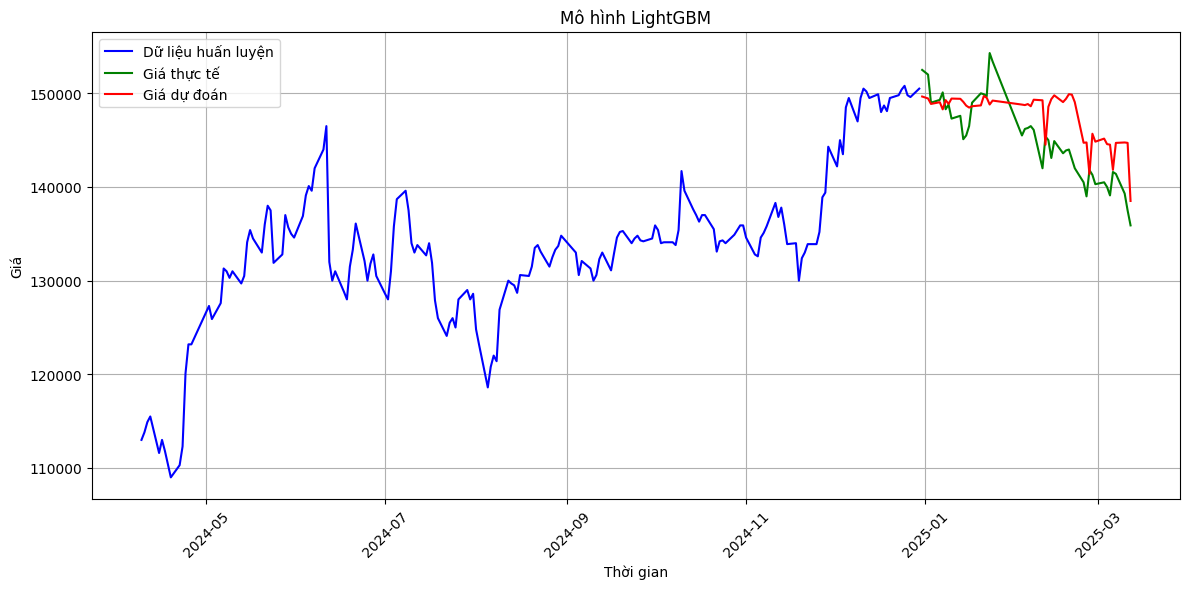

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(dates_train, y_train, label='Dữ liệu huấn luyện', color='blue')
plt.plot(dates_test, y_test, label='Giá thực tế', color='green')
plt.plot(dates_test, y_pred, label='Giá dự đoán', color='red')
plt.title('Mô hình LightGBM')
plt.xlabel('Thời gian')
plt.ylabel('Giá')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

